Faça o upload do arquivo data.pkl com os dados fornecidos para a atividade. Use a célula de comando abaixo após a finalização do upload para a preparação do conteúdo do arquivo no colab.

In [442]:
#=======================
# não altere essa célula
#=======================

import pickle
from torch.utils.data import DataLoader
import numpy as np

with open('data.pkl', 'rb') as handle:
    dataset = pickle.load(handle)

training_data = list(zip(dataset['x'].astype(np.float32),dataset['y']))
test_data = list(zip(dataset['x_test'].astype(np.float32),dataset['y_test']))

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=100, shuffle=False)

O dataset representa uma tarefa de classificação com 10 classes e é composto por um input sequencial com 40 float features e um output inteiro contendo o índice da classe de cada amostra (i.e. de 0 a 9).

In [443]:
for X, y in train_dataloader:
    print(f"Shape of X [N, L]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, L]: torch.Size([32, 40])
Shape of y: torch.Size([32]) torch.int64


o formato de cada amostra é 

40 -> Tamanho da entrada

32 -> Tamanho do batch

4000 -> Número de amostras


LENDO O LIVRO UNDERSTANDING DEEP LEARNING, FOI PERCEBIDO QUE OS DADOS TEM AS MESMAS INFORMAÇÕES DO MNIST-1D, E PROVAVELMENTE SÃO O MNIST-1D

In [444]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


Altere as classes abaixo implementando os seguintes modelos:

1. modelo de classificação linear
2. mlp com no máximo 20k parâmetros (contando pesos e biases)
3. rede convolucional estilo LeNet
4. rede convolucional estilo VGG
5. rede convolucional estilo ResNet

(extra)
6. rede recorrente
7. rede estilo ViT

In [578]:
class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pesos = nn.Linear(40, 10, bias=True)

    def forward(self, x):
        x = self.pesos(x)  # Aplicar os pesos e bias, sem função de ativação
        return x

class MLPNet(nn.Module):
    def __init__(self):
        super().__init__()
        '''Nessa rede temos ao total 18.760 parâmetros, para obter esse número basta contar a quantidade de neurônios multiplicado pela quantidade de entradas + 1 (bias), isso para cada camada da rede. Asim, temos:
            200 * 41 = 8.200
            50 * 201 = 10.050
            10 * 51 = 510
            
            Somando tudo temos os 18.760 parâmetros descritos, incluindo pesos e bias.'''
        
        self.fc1 = nn.Linear(40, 200, bias = True)
        self.fc2 = nn.Linear(200, 50, bias = True)
        self.fc3 = nn.Linear(50, 10, bias = True)
        
        '''fc é uma abraviação para fully conected (totalmente conectada), que é o conceito de uma mlp, onde todas as entradas estão conectadas atráves de um peso a cada neurônio, e cada saída de uma camada pode ser entrada para uma proxima.'''

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # Não requer função softmax, pois a mesma já está implicita na escolha da loss como CrossEntropyLoss
        return x 

# Define model
    
class LeNet(nn.Module):
    '''Em um alto nível, o LeNet (LeNet-5) consiste em duas partes: um codificador convolucional consistindo de duas camadas convolucionais; e um bloco denso consistindo de três camadas totalmente conectadas. Além disso contamos com as camadas de pooling e funções de ativação, no paper original é utilizado sigmoid/tangente hiperbólica, nessa implementação usaremos a relu, como também, usaremos a conv1d, pois se tratam de dados não bidimensionais . Um ponto de extrema atenção, é que ReLUs e max-pooling ainda não haviam sido descobertos na idealização da LeNet, mas serão utilizadas, pois geram um bom aumento de desempenho, juntamente com a softmax presente na função de perca, diferente do decodificador gaussiano, inicialmente proposto. Além disso, a arquitetura segue o seguinte modelo:
        
        Primeira Camada Convolucional: a primeira camada convolucional possui 6 filtros 1x5 com stride 1 e padding 2, essa escolha foi feita para manter o resultado da convolução com o mesmo tamanho de sua entrada (40). Assim, se assemelhando mais a resnet tradicional que após a primeira convolução, gera um feature map de 6 por 28x28 (mesmo tamanho da entrada).
        
        Primeira Camada de pooling: a primeira camada de pooling é um max_pooling 1x2 com stride 2, assim reduzindo o tamanho de x pela metade (20), assim como na publicação da resnet.
        
        Segunda Camada Convolucional: a segunda camada convolucional implementa 16 filtros 1x5, com stride 1 e padding 0, assim reduzindo o tamanho de x para 16x16, onde temos 16 mapas de taamnho 16 cada. Redução proporcional a resnet original
        
        Segunda Camada de pooling: a segunda camada de pooling é um max_pooling 1x2 com stride 2, reduzindo x para 16x8, 16 mapas com 8 de tamanho cada, tendo papel semelhante a da implementação original que reduz o resultado da segunda camada convolucional pela metade.
        
        A partir dai as features sofrem um flatten (achatamento) e servirão de entrada para uma totalmente conectada (mlp), essa totalmente conectada tem :
        
            Primeira camada mlp: 50 neurônios com 16*8 pesos cada, quantidade de "features" que temos após aplicar a segunda camada de pooling. 
            Segunda camada mlp: 30 neurônios com 50 pesos cada, quantidade de neurônios da camada anterior. 
            Terceira camada mlp: 10 neurônios (quantidade de classes) com 30 pesos cada, quantidade de neurônios da camada anterior. 
            
            O número de neurônios da totalmente conectada foi reduzido, visto que na original haviam 120, 84 e 10 neurônios por cada, isso foi feito a fim de gerar menos parâmetros que a mlp anteriormente implementada.
        '''


    '''Calculo dos parâmetros:
           Para os kernels, temos in_channels * kernel_size * out_channels + out_channles(bias) por camada, assim, temos:
           
                conv1: 1x6x5 + 6 = 36 parâmetros
                conv2: 6x5x16 + 16 = 496 parâmetros
                
                fc1: 50 x (16*8 + 1) = 6450 parâmetros
                fc2: 30 x 51 = 1530 parâmetros
                fc3: 10 x 31 = 310 parâmetros
                
            Desse modo, nossa lenet possui 8.822 parâmetros, contabilizando pesos e bias, sendo mais de 2 vezes menor que a mlp implementada.
                '''
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2, padding_mode='zeros')  
        self.conv2 = nn.Conv1d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)

        self.fc1 = nn.Linear(16 * 8, 50, bias = True)
        self.fc2 = nn.Linear(50, 30, bias = True)
        self.fc3 = nn.Linear(30, 10, bias = True)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Reshape para [batch_size, 1, 40]

        x = F.relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = F.relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = x.view(x.size(0), -1)  # Achata o tensor antes das camadas totalmente conectadas

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Não requer função softmax, pois a mesma já está implicita na escolha da loss como CrossEntropyLoss

        return x

class VGGNet(nn.Module):
    '''A VGG segue a ideia de usar muitas camadas convolucionais com filtros pequenos, aumentando a profundidade da rede e surge também com a ideia da utilização de "blocos", onde o blocco de construção básico das CNNs é uma sequência do seguinte:
        uma camada convolucional com padding para manter a resolução, 
        uma função de ativação, como uma ReLU, 
        uma camada de pooling como max-pooling para reduzir a resolução. Um dos problemas com essa abordagem é que a resolução espacial diminui muito rapidamente, isso impõe um limite de camadas convolucionais na rede. Por exemplo, no caso do ImageNet, seria impossível ter mais de 8 camadas convolucionais dessa forma.
        
        Assim como a AlexNet (sua antecessora) e a LeNet, a VGG pode ser particionada em duas partes: a primeira consistindo de camadas convolucionais e de pooling e a segunda consistindo de camadas totalmente conectadas. Em um alto nível, podemos enxergar como se as camadas convolucionais tivessem o papel de entregar as melhores features para aquelas tarefas (features essas que serão aprendidas pelo backpropagation) e a totalmente conectada o papel de classificar baseado nessas features entregues, esse paralelo serve também para a Lenet.
        A principal diferença, além do ganho de profundidade da rede está em que as camadas convolucionais são agrupadas em transformações não lineares que deixam a dimensionalidade inalterada, seguidas por uma etapa de redução de resolução. 
        
        Para essa implementação serão usados 3 blocos, onde serão combinadas convs e funções de ativação, e ao final de cada bloco, teremos uma max_pooling com kernel 1x2 e stride 2, reduzindo sempre pela metade o tamanho da entrada. Detalhe é que as convs sempre possuem o mesmo kernel_size e geram mapas com a mesma dimensão de entrada, a redução da resolução fica por conta da max_pooling ao final de cada bloco.
        
        Para a totalmente conectada serão usados 3 camadas, com 4096, 4096 e 10 neurônios respectivamente. Como novidade, há a utilização do dropout a fim de trazer uma regularização a rede, uma visão interessante sobre o mesmo é que pode ser visto como um "ensemble" de redes neurais.
        '''


    '''Calculo dos parâmetros:
       Para os kernels, temos in_channels * kernel_size * out_channels + out_channles(bias) por camada, assim, temos:
       
            conv1: 1x64x3 + 64 = 192 parâmetros
            conv2: 64x64x3 + 64 = 12.288 parâmetros
            conv3: 64x128x3 + 128 = 24.576 parâmetros
            conv4: 128x128x3 + 128 = 49.152 parâmetros
            conv5: 128x256x3 + 256 = 98.304 parâmetros
            conv6: 256x256x3 + 256 = 196.608 parâmetros
            conv7: 256x256x3 + 256 = 196.608 parâmetros
            
            
            fc1: 4096 x (256*5 + 1) = 5.431.296 parâmetros
            fc2: 4096 x 4097 = 16.781.312 parâmetros
            fc3: 10 x 4097 = 40.970 parâmetros
            
        Desse modo, nossa VGG com 3 blocos possui 22.831.306 parâmetros, contabilizando pesos e bias, sendo absurdamente maior que as demais redes implementadas, muito graças ao tamanho de sua totalmente conectada.
            '''
    
    '''A vgg implementada segue uma convnet do tipo C, mas sem o quarto bloco vgg, essa escolha de "capar" o último bloco se da pela quantidade de parâmetros de entrada para a mlp, visto que baixar mais ainda a resolução de entrada resultaria em uma resolução de 2 ou 3 em 512 mapas, nos nossos testes essa rede desempenhou pior, além de trazer esse fator pode contribuir com vanish gradient.'''


    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            #Primeiro bloco VGG
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),

            # Segundo bloco VGG
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),

            #Terceiro bloco VGG
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )

        '''No último bloco VGG, temos como saída 256 mapas de features, como são 3 blocos ao longo da rede, onde cada bloco reduz a resolução em 2x temos como entrada no primeiro bloco um tamanho de 40, no segundo um tamanho de 20, no terceiro um tamanho de 10, e na primeira camada da totalmente conectada temos 5, isso para cada mapa de features, o que resulta na entrada de tamanho 256x5 '''
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 5, 4096),  
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)  # Camada de saída com 10 neurônios (para 10 classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Reshape para [batch_size, 1, 40]
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Achata o tensor antes das camadas totalmente conectadas
        x = self.fc_layers(x)
        return x
    
class ResNet(nn.Module):
    '''A medida que a rede fica mais profunda, ela é capaz de aproximar um conjunto maior de funções, e em teoria ficar mais "poderosa", contudo, foi observado que isso não era necessáriamente verdade, uma das principais hípoteses é de que para uma rede altamente profunda, mudar um pouco a entrada pode gerar um gradiente completamente diferente. Isso não costuma acontecer nas redes mais rasas, visto que os gradientes são mais correlacionados, mas essa correlação cai rapidamente para zero para redes profundas, fenômeno conhecido como shattered gradients. A maneira de se resolver isso nas conexões residuais é transformando a rede original em um conjunto de redes menores cujas saídas são somadas para calcular o resultado.    
    Além disso, está incluso a camada de batch normalization, que mesmo com princípios falhos do artigo, busca resolver as diferenças de magnitude entre camadas, por exemplo, se uma camada tiver ativações variáveis que são 100 vezes maiores que as de outra camada, isso pode necessitar de ajustes compensatórios nas taxas de aprendizado. Um fato interessante é que a batch norm mitiga a necessidade de uma inicialização correta dos pesos.
    Ainda assim, a implementação tomou como base a implementação anterior da vgg, mas adicionando um novo "bloco". Nas arquiteturas ResNet, incluindo a nossa adaptação, as conexões residuais funcionam adicionando a saída de um bloco de camadas convolucionais à sua entrada, efetivamente permitindo que o bloco aprenda uma função de "perturbação" da identidade ao invés de aprender diretamente a transformação desejada. Isso ajuda a mitigar o problema dos shattered gradients
    Em nossa rede, cada bloco residual consiste em duas camadas convolucionais seguidas por uma batch_norm e ativação ReLU. A saída destas duas camadas é então somada com a entrada do bloco através de um atalho, que é ajustado para alinhar as dimensões quando necessário usando uma convolução 1x1.
    '''

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.layer1_1 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm1d(64)
        self.layer1_2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm1d(64)

        self.layer2_1 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn2_1 = nn.BatchNorm1d(128)
        self.layer2_2 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm1d(128)

        self.layer3_1 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn3_1 = nn.BatchNorm1d(256)
        self.layer3_2 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm1d(256)

        self.layer4_1 = nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1)
        self.bn4_1 = nn.BatchNorm1d(512)
        self.layer4_2 = nn.Conv1d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm1d(512)

        self.fc_layers = nn.Sequential(
            nn.Linear(512 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)  # Camada de saída com 10 neurônios (para 10 classes)
        )

        self.shortcut1 = nn.Sequential()
        self.shortcut2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=1, stride=2),
            nn.BatchNorm1d(128)
        )
        self.shortcut3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=1, stride=2),
            nn.BatchNorm1d(256)
        )
        self.shortcut4 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=1, stride=2),
            nn.BatchNorm1d(512)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Ajuste o input para 1D
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self._residual_block(x, self.layer1_1, self.bn1_1, self.layer1_2, self.bn1_2, self.shortcut1)
        x = self._residual_block(x, self.layer2_1, self.bn2_1, self.layer2_2, self.bn2_2, self.shortcut2)
        x = self._residual_block(x, self.layer3_1, self.bn3_1, self.layer3_2, self.bn3_2, self.shortcut3)
        x = self._residual_block(x, self.layer4_1, self.bn4_1, self.layer4_2, self.bn4_2, self.shortcut4)

        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

    def _residual_block(self, x, conv1, bn1, conv2, bn2, shortcut):
        residual = shortcut(x)
        x = self.relu(bn1(conv1(x)))
        x = bn2(conv2(x))
        x += residual
        x = self.relu(x)
        return x

class RecurrentNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = 128
        self.i2h = nn.Linear(40, 128)
        self.h2h = nn.Linear(128, 128)
        self.h2o = nn.Linear(128, 10)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        batch_size = input.size(0)
        hidden = self.initHidden(batch_size)
        output, hidden = self.step(input, hidden)
        return output

    def step(self, input, hidden):
        hidden = torch.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self, batch_size):
        return torch.zeros(batch_size, self.hidden_size).to(device)
    
# Define model
class ViTNet(nn.Module):
    def __init__(self):
        super().__init__()
        #TODO

    def forward(self, x):
        #TODO
        pass

Escolha o modelo implementado, a função de custo e o otimizador e treine o modelo até atingir a melhor acurácia possível no conjunto de teste.

In [667]:
# altere o modelo nessa célula
model = VGGNet().to(device)
print(model)

VGGNet(
  (conv_layers): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU(inplace=True)
    (7): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): ReLU(inplace=True)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): ReLU(inplace=True)
    (12): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): ReLU(inplace=True)
    (14): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (15): ReLU(inplace=True)
    (16): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers)

In [668]:
# altere a função de custo e o otimizador nessa célula
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

In [669]:
#=======================
# não altere essa célula
#=======================

def train(dataloader, model, loss_fn, optimizer):
    train_loss = []
    train_acc = []

    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += [loss.item()]

        correct = (pred.argmax(1) == y).type(torch.float).mean().item()
        train_acc += [100*correct]

    return train_loss, train_acc

In [670]:
#=======================
# não altere essa célula
#=======================

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    test_acc = 100*correct/size

    return test_loss, test_acc

Escolha o número de épocas para o treinamento.

In [671]:
epochs = 50

In [672]:
train_loss_hist = []
train_acc_hist = []

test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
test_loss_hist = [test_loss_0]
test_acc_hist = [test_acc_0]

print(f"Initial Test Loss: {test_loss_0:.4f}, Initial Test Accuracy: {test_acc_0:.4f}")

for t in range(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    train_loss_hist.append(np.mean(train_loss))
    train_acc_hist.append(np.mean(train_acc))

    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    test_loss_hist.append(test_loss)
    test_acc_hist.append(test_acc)
    if t % 5 == 0:
        print(f"Epoch {t+1}/{epochs}:")
        print(f"Train Loss: {train_loss_hist[-1]:.4f}, Train Accuracy: {train_acc_hist[-1]:.4f}")
        print(f"Test Loss: {test_loss_hist[-1]:.4f}, Test Accuracy: {test_acc_hist[-1]:.4f}")
        print('')

train_loss_hist = np.array(train_loss_hist)
test_loss_hist = np.array(test_loss_hist)
train_acc_hist = np.array(train_acc_hist)
test_acc_hist = np.array(test_acc_hist)

print("\nFinal Results")
print(f"Final Train Loss: {train_loss_hist[-1]:.4f}, Final Train Accuracy: {train_acc_hist[-1]:.4f}")
print(f"Final Test Loss: {test_loss_hist[-1]:.4f}, Final Test Accuracy: {test_acc_hist[-1]:.4f}")

Initial Test Loss: 2.3027, Initial Test Accuracy: 9.9000
Epoch 1/50:
Train Loss: 2.3040, Train Accuracy: 9.4750
Test Loss: 2.3032, Test Accuracy: 8.9000

Epoch 6/50:
Train Loss: 2.0240, Train Accuracy: 21.8250
Test Loss: 2.0803, Test Accuracy: 17.0000

Epoch 11/50:
Train Loss: 1.3588, Train Accuracy: 42.9500
Test Loss: 1.5498, Test Accuracy: 35.1000

Epoch 16/50:
Train Loss: 0.9298, Train Accuracy: 62.8000
Test Loss: 1.0848, Test Accuracy: 58.6000

Epoch 21/50:
Train Loss: 0.6006, Train Accuracy: 77.7500
Test Loss: 0.3321, Test Accuracy: 90.6000

Epoch 26/50:
Train Loss: 0.5270, Train Accuracy: 84.0250
Test Loss: 0.2852, Test Accuracy: 90.9000

Epoch 31/50:
Train Loss: 0.0646, Train Accuracy: 97.9250
Test Loss: 0.0858, Test Accuracy: 98.2000

Epoch 36/50:
Train Loss: 0.2130, Train Accuracy: 93.8750
Test Loss: 0.0755, Test Accuracy: 97.8000

Epoch 41/50:
Train Loss: 0.0090, Train Accuracy: 99.8000
Test Loss: 0.1458, Test Accuracy: 97.4000

Epoch 46/50:
Train Loss: 0.0195, Train Accuracy

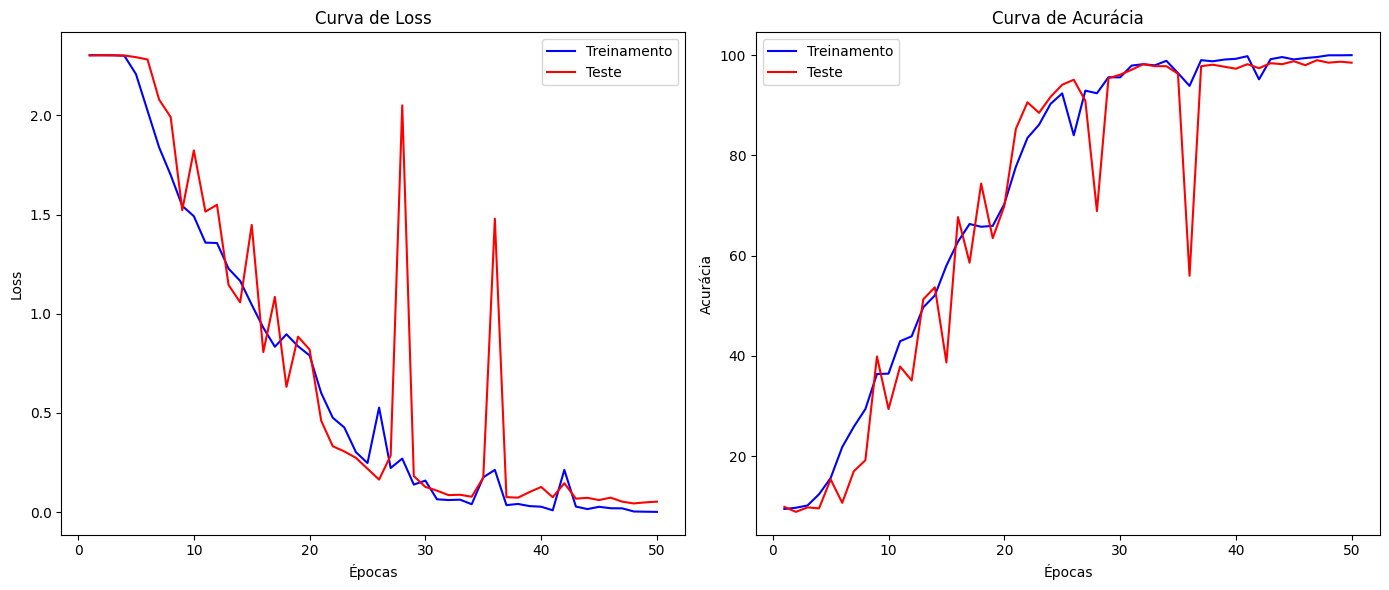

In [674]:
min_length = min(len(train_loss_hist), len(test_loss_hist), len(train_acc_hist), len(test_acc_hist))

train_loss_hist = train_loss_hist[:min_length]
test_loss_hist = test_loss_hist[:min_length]
train_acc_hist = train_acc_hist[:min_length]
test_acc_hist = test_acc_hist[:min_length]

epochs_range = np.arange(1, min_length + 1)

# Plotar as curvas de perda (loss) e acurácia (accuracy) ao longo das épocas
plt.figure(figsize=(14, 6))

# Plotar perda (loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_hist, label='Treinamento', color='blue')
plt.plot(epochs_range, test_loss_hist, label='Teste', color='red')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva de Loss')
plt.legend()

# Plotar acurácia (accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_hist, label='Treinamento', color='blue')
plt.plot(epochs_range, test_acc_hist, label='Teste', color='red')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Curva de Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

# IMPLEMENTAÇÕES PARA TESTE

In [636]:
'''As implementações da VGG e da RESnet feitas anteriormente não são parametrizáveis, para contribuir nos testes, decidimos refazer esses dois modelos de modo que seja possível parametrizar na vgg a quantidade de blocos e na RESNET a profundidade da rede, optamos também por fazer uma versão da vgg com batch normalization, para que assim, possamos obter comparações justas entre vgg e resnet, além disso, as redes abaixo possuem mesma arquitetura, a diferença é que a vgg_bn possui uma camada de batch_norm entre as convs e a resnet_custom possui ligações residuais entre as camadas'''

class VGG(nn.Module):
    def __init__(self, blocos):
        '''
        A rede recebe como parâmetro uma lista, o tamanho da lista é a quantidade de blocos vgg que possuimos, e em cada posição recebemos a quantidade de convs naquele bloco. Por exemplo, para replicar a rede feita no exercício acima, basta instanciar essa rede com parâmetro = [2, 2, 3]
        '''
        super().__init__()

        layers = []
        in_channels = 1
        out_channels = 64

        '''Para cada bloco e cada conv presente no bloco a rede recebe a própria conv e a camada relu de ativação, além disso, a cada bloco, o número de canais de saída é duplicado, mantendo a estrutura da rede vgg, como também a rede recebe uma camada de maxpool que reduz a dimensão do x pela metade, por possuir stride 2 e kernel 2'''
        for i, num_conv_layers in enumerate(blocos):
            for _ in range(num_conv_layers):
                layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels 
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2

        self.conv_layers = nn.Sequential(*layers) # criando um modulo sequencial no pytorch onde passaremos cada camada individualmente como argumento (presença do *layers).

        self._to_linear = self._calculate_conv_output_size(40) # Retornando tamanho da entrada para a totalmente conectada, passando o tamanho do input(40)

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Reshape para [batch_size, 1, 40]
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Achata o tensor antes das camadas totalmente conectadas
        x = self.fc_layers(x)
        return x

class VGG_bn(nn.Module):
    '''Implementando a mesma vgg acima, mas adicionando camadas de batch_normaliation, repare que o codigo é literalmente o mesmo com a adição da batch_norm entre cada conv e relu'''
    def __init__(self, blocos):
        super().__init__()

        layers = []
        in_channels = 1
        out_channels = 64

        for i, num_conv_layers in enumerate(blocos):
            for _ in range(num_conv_layers):
                layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.BatchNorm1d(out_channels)) # LINHA ADICIONADA
                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2

        self.conv_layers = nn.Sequential(*layers)

        self._to_linear = self._calculate_conv_output_size(40)

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

class ResNet_custom(nn.Module):
    '''
    Vale ressaltar que essa rede é praticamente identica a VGG_bn, que é a vgg com batch_norm, contudo, adiciona conexões residuais entre camadas. Um dos desafios da implementação dessa rede foi o de trabalhar com a dimensão das comadas residuais.
       '''
    def __init__(self, blocos):
        super(ResNet_custom, self).__init__()

        self.layers = []
        in_channels = 1  # Iniciando com 1 canal de entrada
        out_channels = 64  # Primeira camada expansível para 64 canais

        for num_conv_layers in blocos:
            block_layers = []  # Camadas deste bloco específico
            for _ in range(num_conv_layers):
                block_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1))
                block_layers.append(nn.BatchNorm1d(out_channels))
                block_layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels  # Atualiza in_channels para o próximo loop

            # Definindo a camada de adaptação se necessário
            if in_channels != out_channels:
                # Atualizar o número de in_channels para combinar com os out_channels após o bloco
                residual_layer = nn.Sequential(
                    nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=2),
                    nn.BatchNorm1d(out_channels)
                )
            else:
                residual_layer = nn.Identity()

            block_layers.append(residual_layer)
            self.layers.extend(block_layers)  # Adicionar as camadas do bloco à lista geral de camadas
            self.layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2  # Dobrar os out_channels para o próximo bloco

        self.conv_layers = nn.Sequential(*self.layers)  # Cria uma sequência com todas as camadas convolucionais
        self._to_linear = self._calculate_conv_output_size(40)
        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        for layer in self.conv_layers:
            if isinstance(layer, nn.Sequential) and len(layer) == 2:
                x = layer(x) + x  # Aplicar a camada e somar com o residual
            else:
                x = layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


In [661]:

def treina(model):
    resultdos = {}

    train_loss_hist = []
    train_acc_hist = []
    
    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]
    
    print(f"Initial Test Loss: {test_loss_0:.4f}, Initial Test Accuracy: {test_acc_0:.4f}")
    
    for t in range(epochs):
        train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
        train_loss_hist.append(np.mean(train_loss))
        train_acc_hist.append(np.mean(train_acc))
    
        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)
        if t % 10 == 0:
            print(f"Epoch {t+1}/{epochs}:")
            print(f"Train Loss: {train_loss_hist[-1]:.4f}, Train Accuracy: {train_acc_hist[-1]:.4f}")
            print(f"Test Loss: {test_loss_hist[-1]:.4f}, Test Accuracy: {test_acc_hist[-1]:.4f}")
            print('')
    
    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)
    
    print("\nFinal Results")
    print(f"Final Train Loss: {train_loss_hist[-1]:.4f}, Final Train Accuracy: {train_acc_hist[-1]:.4f}")
    print(f"Final Test Loss: {test_loss_hist[-1]:.4f}, Final Test Accuracy: {test_acc_hist[-1]:.4f}")
    
    resultados = {
        'train_loss_hist': train_loss_hist,
        'train_acc_hist': train_acc_hist,
        'test_loss_hist': test_loss_hist,
        'test_acc_hist': test_acc_hist,
    }
    
    return resultados

In [662]:
def plota_loss_acuracia(resultados):
    train_loss_hist = resultados['train_loss_hist']
    train_acc_hist = resultados['train_acc_hist']
    test_loss_hist = resultados['test_loss_hist']
    test_acc_hist = resultados['test_acc_hist']
    
    min_length = min(len(train_loss_hist), len(test_loss_hist), len(train_acc_hist), len(test_acc_hist))
    
    train_loss_hist = train_loss_hist[:min_length]
    test_loss_hist = test_loss_hist[:min_length]
    train_acc_hist = train_acc_hist[:min_length]
    test_acc_hist = test_acc_hist[:min_length]
    
    epochs_range = np.arange(1, min_length + 1)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss_hist, label='Treinamento', color='blue')
    plt.plot(epochs_range, test_loss_hist, label='Teste', color='red')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title('Curva de Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_acc_hist, label='Treinamento', color='blue')
    plt.plot(epochs_range, test_acc_hist, label='Teste', color='red')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.title('Curva de Acurácia')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    
def compara_loss(resultado1, resultado2, modelo1='', modelo2=''):
    train_loss_hist1 = resultado1['train_loss_hist']
    test_loss_hist1 = resultado1['test_loss_hist']

    
    train_loss_hist2 = resultado2['test_loss_hist']
    test_loss_hist2 = resultado2['test_acc_hist']

    min_length = min(len(train_loss_hist1), len(test_loss_hist1), len(train_loss_hist2), len(test_loss_hist2))

    train_loss_hist1 = train_loss_hist[:min_length]
    test_loss_hist1 = test_loss_hist[:min_length]

    train_loss_hist2 = train_acc_hist[:min_length]
    test_loss_hist2 = test_acc_hist[:min_length]

    epochs_range = np.arange(1, min_length + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss_hist1, label=f'Loss treino modelo: {modelo1}', color='blue')
    plt.plot(epochs_range, train_loss_hist2, label=f'Loss treino modelo: {modelo2}', color='red')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title('Curva de Loss TREINO')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, test_loss_hist1, label=f'Loss teste modelo: {modelo1}', color='blue')
    plt.plot(epochs_range, test_loss_hist2, label=f'Loss teste modelo: {modelo2}', color='red')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title('Curva de Loss TESTE')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [675]:
model = VGGNet().to(device)

In [676]:
vgg = treina(model)

Initial Test Loss: 2.3026, Initial Test Accuracy: 10.6000
Epoch 1/50:
Train Loss: 2.3027, Train Accuracy: 9.5750
Test Loss: 2.3026, Test Accuracy: 10.6000

Epoch 11/50:
Train Loss: 2.3027, Train Accuracy: 9.3500
Test Loss: 2.3026, Test Accuracy: 10.6000



KeyboardInterrupt: 

In [660]:
model = LeNet().to(device)
lenet = treina(model=model)

Initial Test Loss: 2.3043, Initial Test Accuracy: 14.4000
Epoch 1/50:
Train Loss: 2.3044, Train Accuracy: 14.0250
Test Loss: 2.3043, Test Accuracy: 14.4000

Epoch 11/50:
Train Loss: 2.3044, Train Accuracy: 14.0250
Test Loss: 2.3043, Test Accuracy: 14.4000

Epoch 21/50:
Train Loss: 2.3044, Train Accuracy: 14.0250
Test Loss: 2.3043, Test Accuracy: 14.4000

Epoch 31/50:
Train Loss: 2.3044, Train Accuracy: 14.0250
Test Loss: 2.3043, Test Accuracy: 14.4000

Epoch 41/50:
Train Loss: 2.3044, Train Accuracy: 14.0250
Test Loss: 2.3043, Test Accuracy: 14.4000


Final Results
Final Train Loss: 2.3044, Final Train Accuracy: 14.0250
Final Test Loss: 2.3043, Final Test Accuracy: 14.4000


# TESTES E COMPARATIVOS

## LINEAR VS MLP

## MLP VS LENET

## LENET VS VGG

## DIFERENTES TESTES PARA VGGS

### VGG VS RESNET

## RECORRENTE

In [ ]:
'''Essa célula é dedicada'''

In [243]:
''''#=======================
# não altere essa célula
#=======================

from tqdm import trange

train_loss_hist = []
train_acc_hist = []

test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
test_loss_hist = [test_loss_0]
test_acc_hist = [test_acc_0]

for t in trange(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    train_loss_hist += train_loss
    train_acc_hist += train_acc

    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    test_loss_hist += [test_loss]
    test_acc_hist += [test_acc]

train_loss_hist = np.array(train_loss_hist)
test_loss_hist = np.array(test_loss_hist)
train_acc_hist = np.array(train_acc_hist)
test_acc_hist = np.array(test_acc_hist)'''

100%|██████████| 50/50 [00:20<00:00,  2.38it/s]


In [236]:
import matplotlib.pyplot as plt

Execute essa célula para visualizar as curvas de loss.

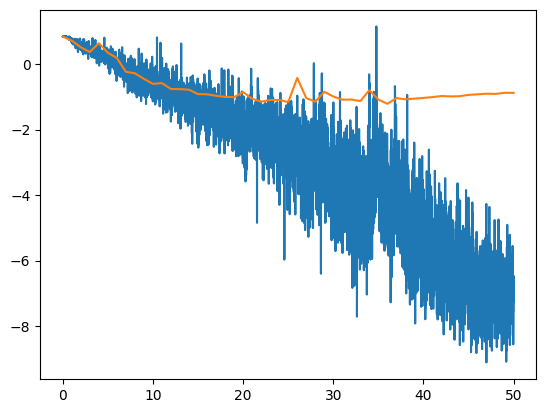

In [244]:
x_axis = np.linspace(0, epochs, len(train_loss_hist))
plt.plot(x_axis, np.log(train_loss_hist))
plt.plot(np.log(test_loss_hist))

Execute essa célula para visualizar as curvas de acurácia.

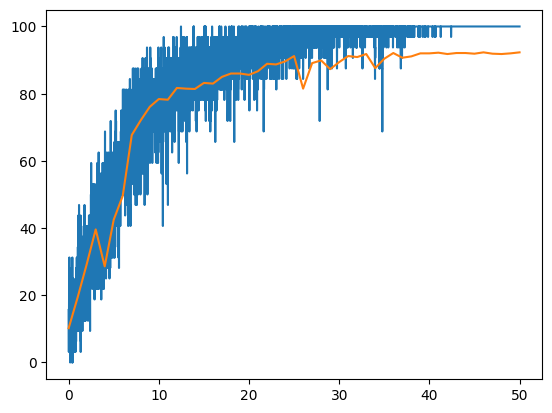

In [245]:
x_axis = np.linspace(0, epochs, len(train_acc_hist))
plt.plot(x_axis, train_acc_hist)
plt.plot(test_acc_hist)

Utilize os códigos acima para comparar os melhores modelos obtidos para cada arquitetura e, assim, faça um resumo das conclusões encontradas a partir dessas comparações.

## Linear (Pérceptron sem ativação) vs MLP

### LINEAR

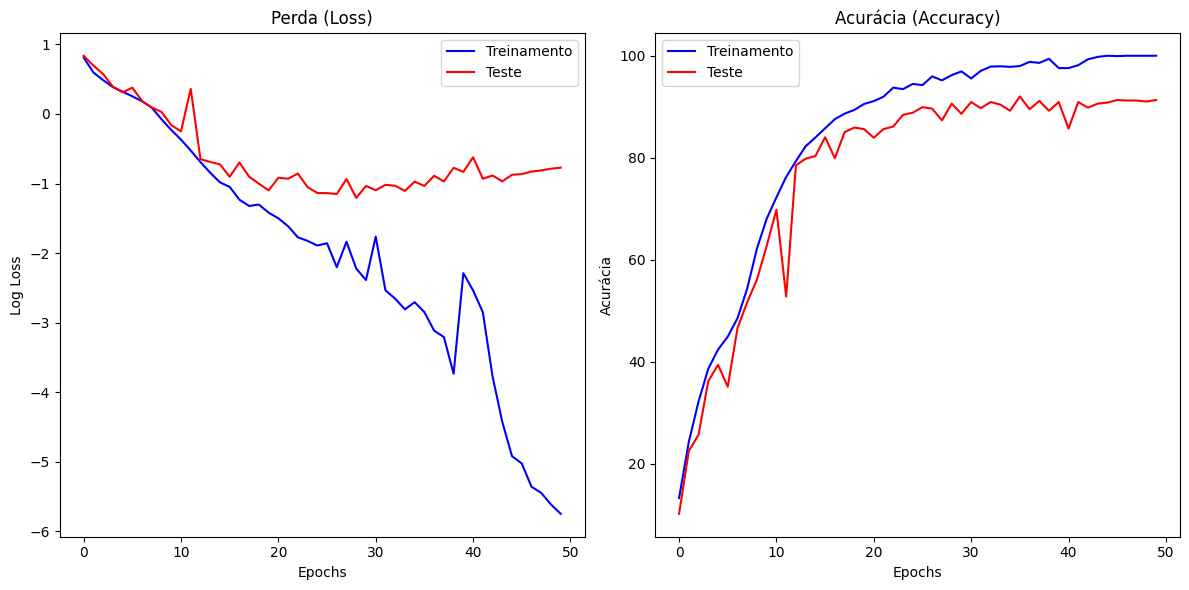

In [72]:
min_length = min(len(train_loss_hist), len(test_loss_hist))

train_loss_hist = train_loss_hist[:min_length]
test_loss_hist = test_loss_hist[:min_length]
train_acc_hist = train_acc_hist[:min_length]
test_acc_hist = test_acc_hist[:min_length]

# Plotar perda (loss)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
x_axis_loss = np.arange(min_length)  # Ajusta o comprimento da lista de perdas
plt.plot(x_axis_loss, np.log(train_loss_hist + 1e-10), label='Treinamento', color='blue')  # Adiciona uma pequena constante para evitar log(0)
plt.plot(x_axis_loss, np.log(test_loss_hist + 1e-10), label='Teste', color='red')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('Perda (Loss)')
plt.legend()

# Plotar acurácia (accuracy)
plt.subplot(1, 2, 2)
x_axis_acc = np.arange(min_length)  # Ajusta o comprimento da lista de acurácias
plt.plot(x_axis_acc, train_acc_hist, label='Treinamento', color='blue')
plt.plot(x_axis_acc, test_acc_hist, label='Teste', color='red')
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.title('Acurácia (Accuracy)')
plt.legend()

plt.tight_layout()
plt.show()

## LENET


É esperado que a LeNet, mesmo com menos parâmetros, tenha um desempenho melhor que uma MLP (Multi-Layer Perceptron). Isso ocorre porque, através da operação de convolução, é possível capturar relações espaciais e temporais entre as posições de entrada de maneira mais eficiente. Nas MLPs, essas relações precisam ser "aprendidas" exclusivamente por meio das conexões entre os neurônios, o que pode ser menos eficaz e exigir mais dados para um bom desempenho.

Além disso, fatores como a invariância são ocntribuintes nesse caso. Por exemplo, se o objetivo for, dado um conjunto de preços de uma determinada ação nos ultimos 40 dias, prever se no dia 41 ela vai subir ou não, uma informação de extrema importância, pode ser se houve ou não queda brusca na ação nos dias analisados. Essa informação é retirada a partir da relação dos dados de entrada, e não propriamente dos valores em si, além disso, a queda brusca pode acontecer em n posições possíveis, o que torna o problema complexo para mlp, demandando uma altissima quantidade de dados para representar a situação, além de precisar "aprender" essa relação. A operação de convolução ajuda bastante nesse problema, resolvendo a relação um para um imposta pela mlp. Esse ponto é favorecido se pensarmos que cada kernel é um neurônio que passeia pelas entradas, assim evitando essa localidade. Com isso, podemos dizer que a rede deve ser 

é possível observar que a mlp atinge 0 de erro no conjunto de treino, se pensarmos na mlp como um aproximador universal de funções, temos que a função formada pelo conjunto de treino é atinigível, mas essa não necessariamente é a função que resolve o problema, isso por que, sabemos que há dependência entre features, o que torna a função extremamente complexa para mlp. Se inserirmos conhecimento (convolução) seremos capazes de atingir um mesmo valor de loss no treino que a mlp, mas com um erro menor no teste. Isso por que, "facilitamos" a função a ser aprendida, quando passamos informações dos pixels ao redor 

Uma das coisas que foi percebida nos testes, em relação a resnet é a importância da camada batch_norm, mesmo que fundalmentamente incorreta quando proposta em seu artigo. Para exemplificar, foi testada uma vgg com um número um pouco maior de blocos, a fim de inserir uma resnet com mesmo tamanho e reproduzir o resultado do paper da resnet o qual uma rede maior desempenhou pior sem as ligações residuais mas melhor quando adicionado as residuais. Por um descuido, a rede não estava exatamente equivalente, visto que a versão da resnet possuia a camada de batch normalization, então o resultado foi bem melhor para a resnet, o que nos gerou a desconfiança de que de fato era a residual que estava impactando tanto. Após isso, decidimos inserir batch_norm na rede vgg que não estava treinando, e apenas com essa adição, a rede desempenhou muito melhor, nos demonstrado que para essa comparação é extremamente necessário que as redes sejam equivalentes.

Outra coisa que foi reparada, é que a VGG possui um treinamento um tanto instável em certos momentos, principalmente se subirmos a quantidade de blocos/camadas. Uma das hípoteses, é que isso pode acontecer devido ao desajuste da learning_rate, e ao estudar batch_norm, vimos que uma das motivações é justamente équiparar essa saída para cada camada da rede, assim, vamos fazer o teste de rodar uma vgg com batch_norm. pois nos testes foi percebido uma relação direta entre performance/convergencia e quantidade de blocos de camadas presentes na rede

#   ABA DE TESTES

Sabemos que uma mlp é um aproximador universal de funções, e que quanto maior a rede maior o conjunto de funções atingíveis, com isso, ao implementar uma linear, que é uma simples reta, o esperado é que se performe pior que uma mlp com algo perto de 20 mil parâmetros e não-linearidade, isso por que, a mlp pode aproximar um conjunto muito maior de funções, inclusive a reta do modelo linear. A afirmação passada é forte, e faz surgir a seguinte dúvida, já que quanto mais parâmetros maior o campo de funções atingíveis, e não conhecemos a nossa função alvo uma rede com mais parâmetros deveria performar melhor que uma rede que possui menos parâmetros, certo? O resultado da lenet com mais de 2 vezes menos parâmetros se mostrou melhor que a mlp duas vezes maior, fato que se deve a inserção das camadas convolucionais. Isso não significa que uma mlp não seja capaz de aproximar a função que descreve nosso evento sobre os dados, mas sim de que isso pode ser muito dificil, devido a maneira como o problema em si existe ou como foi modelado. Para nossos dados (MNIST-1D) sabemos que independente da posição do digito na imagem, a resposta continua igual, sabemos que se deslocado um único pixel a direita, isso não deveria fazer nenhuma diferença dentro do problema, mas quando tratamos de mlp (totalmente conectada) a relação entre os pesos e entrada é de um para um, ou seja, uma imagem com um único píxel deslocada, representa um outro problema para a rede, algo que não acontece com a convolucional, que podemos enxergar como um único (ou vários) neurônio(s) deslizando sobre a entrada, assim eliminando o problema da localidade e utilizando as informações não unitárias para tomada de decisão (detalahar melhor essa ideia de que conv leva em consideração vizinhos)). Mas novamente, não é impossível que a mlp aprenda a função que resolve o problema, mas é muito mais custoso, pois talvez precisemos de dados quase infinitos para cobrir todas as possibilidades da forma que o problema foi modelado, talvez precisemos de muitas épocas para permitir esse aprendizado, quando na pratica, modelar o problema de outra forma pode o tornar resolvível de maneira muito mais simples, onde no fim de tudo, utilizamos a ideia da mlp (aproximador universal) e inserimos noss oconhcimento na modelagem, conhecimento esse, nesse caso, de que a localidade não importa, por exemplo.

### MLP VS LENET (RESULTADO DO UNDERSTANDING DEEP LEARNING)

### IMPACTO DA BATCH_NORM

### REPRODUÇÃO DO RESULTADO DO PAPER DA RESNET


### predição para diferentes valores de N na rnn